Edunet Internship Day 4

In [2]:
# Import library
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [3]:
# Upload CSV file
from google.colab import files

uploaded = files.upload()

Saving global air pollution dataset.csv to global air pollution dataset.csv


In [4]:
# Read the CSV file
df = pd.read_csv("global air pollution dataset.csv")

# Display first five rows
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [5]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


This dataset contains information about air pollution levels in different countries and cities.
It includes AQI values and pollution categories for CO, Ozone, NO2 and PM2.5.

In [9]:
# Check number of rows and columns
print("Shape of Dataset:", df.shape)

# Display first 5 rows
df.head()



Shape of Dataset: (23463, 12)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [10]:
# Display last 5 rows
df.tail()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
23458,India,Gursahaiganj,184,Unhealthy,3,Good,154,Unhealthy,2,Good,184,Unhealthy
23459,France,Sceaux,50,Good,1,Good,20,Good,5,Good,50,Good
23460,India,Mormugao,50,Good,1,Good,22,Good,1,Good,50,Good
23461,United States of America,Westerville,71,Moderate,1,Good,44,Good,2,Good,71,Moderate
23462,Malaysia,Marang,70,Moderate,1,Good,38,Good,0,Good,70,Moderate


In [11]:
# Statistical summary of numerical columns
df.describe()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


Generalization of Dataset

1. The dataset contains air pollution information of different countries and cities.
2. AQI Value represents the Air Quality Index.
3. AQI Category indicates whether air quality is Good, Moderate, Poor etc.
4. CO, NO2, Ozone and PM2.5 values are important pollutants.
5. Higher AQI generally indicates poorer air quality.
6. Pollution values may affect AQI category.

In [12]:
# Count missing values in each column
df.isnull().sum()

,0
Country,427
City,1
AQI Value,0
AQI Category,0
CO AQI Value,0
CO AQI Category,0
Ozone AQI Value,0
Ozone AQI Category,0
NO2 AQI Value,0
NO2 AQI Category,0


The Country column contained 427 missing values and the City column contained 1 missing value.
Since both columns are categorical, missing values were replaced using the Mode (most frequent value). This preserves the dataset without removing rows.

In [13]:
# Fill missing values in Country and City using Mode (Most Frequent Value)

df["Country"] = df["Country"].fillna(df["Country"].mode()[0])
df["City"] = df["City"].fillna(df["City"].mode()[0])

# Check whether missing values are removed
df.isnull().sum()

,0
Country,0
City,0
AQI Value,0
AQI Category,0
CO AQI Value,0
CO AQI Category,0
Ozone AQI Value,0
Ozone AQI Category,0
NO2 AQI Value,0
NO2 AQI Category,0


Reason:
Country and City are categorical columns. Missing values are filled using Mode because it replaces missing data with the most frequently occurring value.

In [14]:
# Create a new feature called Total Pollution Index

df["Total Pollution Index"] = (
    df["CO AQI Value"] +
    df["Ozone AQI Value"] +
    df["NO2 AQI Value"] +
    df["PM2.5 AQI Value"]
)

# Display first 5 rows
df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Total Pollution Index
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,88
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,48
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate,108
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good,55
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good,28


Reason:
A new feature named Total Pollution Index is created to represent the overall pollution level by combining all pollutant AQI values.

In [15]:
#

# Convert categorical columns into numerical values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    "Country",
    "City",
    "AQI Category",
    "CO AQI Category",
    "Ozone AQI Category",
    "NO2 AQI Category",
    "PM2.5 AQI Category"
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Total Pollution Index
0,130,16525,51,2,1,0,36,0,0,0,51,2,88
1,22,16546,41,0,1,0,5,0,1,0,41,0,48
2,75,16582,66,2,1,0,39,0,2,0,66,2,108
3,123,16618,34,0,1,0,34,0,0,0,20,0,55
4,54,16699,22,0,0,0,22,0,0,0,6,0,28


In [16]:
#scalling

# Scale numerical columns using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = [
    "AQI Value",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value",
    "Total Pollution Index"
]

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

df.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Total Pollution Index
0,130,16525,-0.374832,2,-0.201071,0,0.028696,0,-0.583048,0,-0.319731,2,-0.282695
1,22,16546,-0.553232,0,-0.201071,0,-1.074581,0,-0.392717,0,-0.502229,0,-0.844011
2,75,16582,-0.107233,2,-0.201071,0,0.135464,0,-0.202386,0,-0.045985,2,-0.002037
3,123,16618,-0.678111,0,-0.201071,0,-0.042484,0,-0.583048,0,-0.885473,0,-0.745781
4,54,16699,-0.892190,0,-0.746915,0,-0.469558,0,-0.583048,0,-1.140970,0,-1.124670


In [17]:
# Display correlation between numerical columns

df.corr(numeric_only=True)

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Total Pollution Index
Country,1.000000,0.020185,-0.122901,-0.098666,-0.049264,0.004923,-0.078035,-0.133271,0.137063,-0.017647,-0.124674,-0.097025,-0.117797
City,0.020185,1.000000,-0.024019,-0.024456,-0.003459,-0.004994,0.008085,-0.003313,0.014028,0.001852,-0.030546,-0.027894,-0.019355
AQI Value,-0.122901,-0.024019,1.000000,0.638692,0.430602,0.066663,0.405310,0.415757,0.231758,0.087561,0.984327,0.643985,0.944855
AQI Category,-0.098666,-0.024456,0.638692,1.000000,0.360858,0.004630,0.304928,0.364522,0.288758,0.039630,0.670902,0.976162,0.666681
CO AQI Value,-0.049264,-0.003459,0.430602,0.360858,1.000000,0.550709,0.145724,0.214086,0.488092,0.288518,0.438557,0.355763,0.456377
CO AQI Category,0.004923,-0.004994,0.066663,0.004630,0.550709,1.000000,0.010171,0.015515,0.052124,0.210628,0.064642,0.000911,0.071717
Ozone AQI Value,-0.078035,0.008085,0.405310,0.304928,0.145724,0.010171,1.000000,0.853122,-0.181818,-0.026399,0.339887,0.265576,0.645991
Ozone AQI Category,-0.133271,-0.003313,0.415757,0.364522,0.214086,0.015515,0.853122,1.000000,-0.044585,-0.007428,0.368181,0.301520,0.621710
NO2 AQI Value,0.137063,0.014028,0.231758,0.288758,0.488092,0.052124,-0.181818,-0.044585,1.000000,0.271845,0.260127,0.294892,0.214608
NO2 AQI Category,-0.017647,0.001852,0.087561,0.039630,0.288518,0.210628,-0.026399,-0.007428,0.271845,1.000000,0.091000,0.040137,0.087024


Generalization and Analysis of Global Air Pollution Dataset

1. The dataset contains air quality information from different countries and cities around the world.

2. Each row represents the air quality status of a particular city.

3. "Country" identifies the country where the city is located.

4. "City" specifies the location where pollution measurements were recorded.

5. "AQI Value" represents the overall Air Quality Index. A higher AQI Value indicates poorer air quality.

6. "AQI Category" classifies the AQI Value into categories such as Good, Moderate, Poor, etc.

7. "CO AQI Value" shows the pollution level caused by Carbon Monoxide (CO).

8. "CO AQI Category" describes the air quality category based on CO AQI Value.

9. "Ozone AQI Value" represents the pollution level due to Ozone (O₃).

10. "Ozone AQI Category" indicates the category of ozone pollution.

11. "NO2 AQI Value" measures pollution caused by Nitrogen Dioxide (NO₂).

12. "NO2 AQI Category" classifies NO₂ pollution levels.

13. "PM2.5 AQI Value" measures fine particulate matter pollution, which has a major impact on human health.

14. "PM2.5 AQI Category" represents the pollution category based on PM2.5 concentration.

15. The pollutant AQI values (CO, Ozone, NO2, and PM2.5) collectively influence the overall AQI Value.

16. Higher pollutant values generally result in a higher AQI Value and a poorer AQI Category.

17. Cities with lower pollutant values usually fall into the Good AQI Category, while cities with higher pollutant values fall into Moderate, Poor, or worse categories.

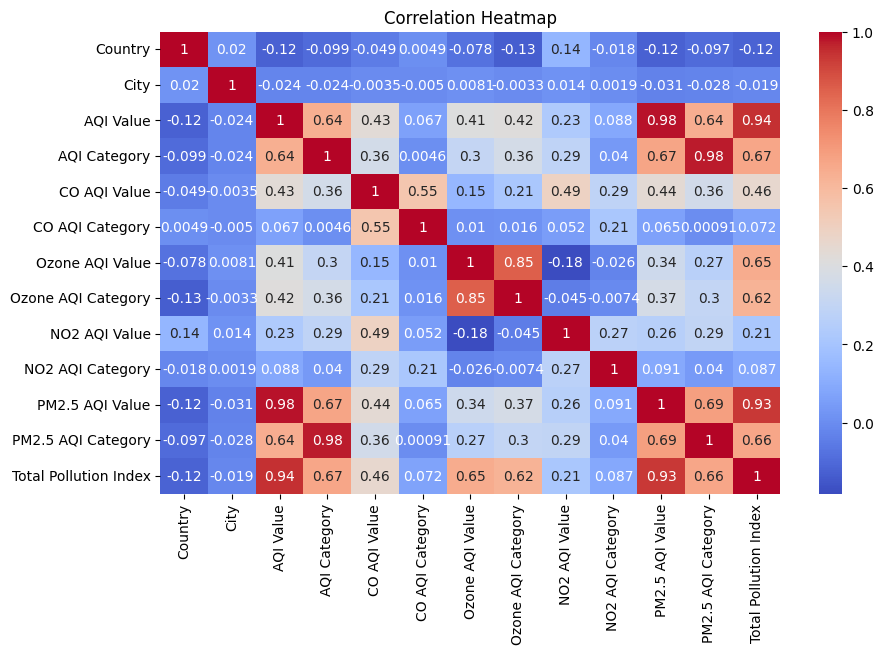

In [18]:
# Visualize correlation using Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Heatmap is used to understand the relationship between numerical features.
Strong positive or negative values indicate high correlation.

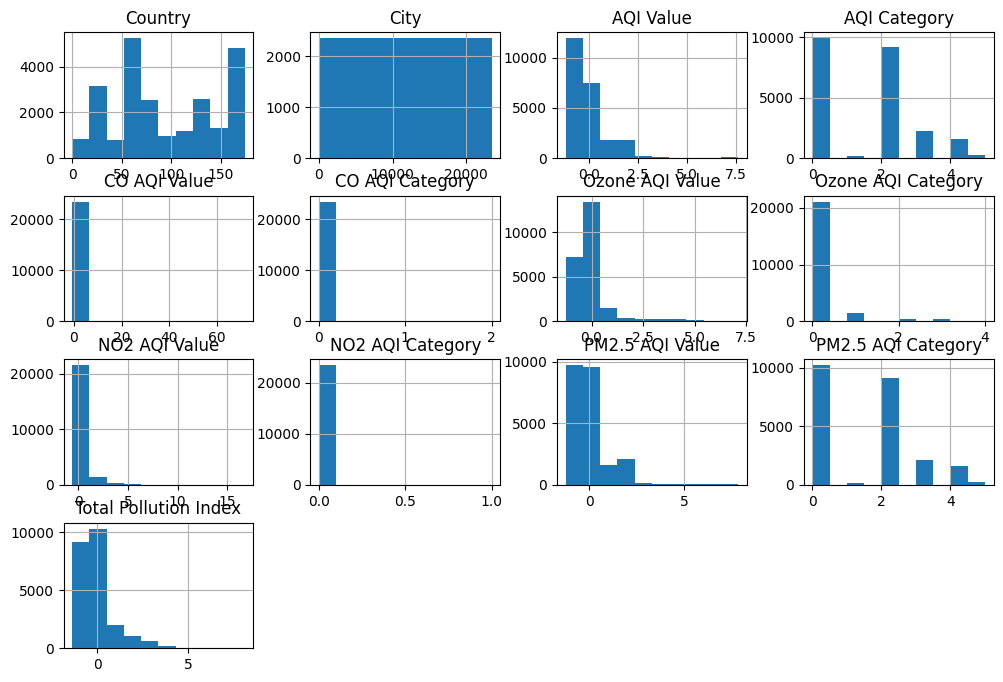

In [19]:
# Display distribution of numerical columns

df.hist(figsize=(12,8))
plt.show()

Histogram helps us understand the distribution of numerical features.

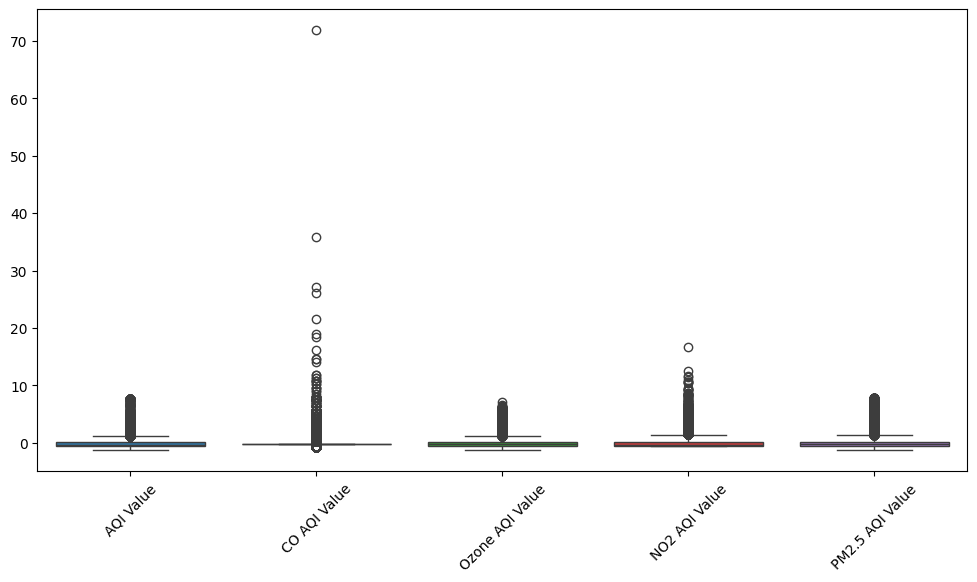

In [20]:
# Detect outliers in numerical columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[["AQI Value",
                     "CO AQI Value",
                     "Ozone AQI Value",
                     "NO2 AQI Value",
                     "PM2.5 AQI Value"]])

plt.xticks(rotation=45)
plt.show()

Boxplot helps identify outliers in the dataset.

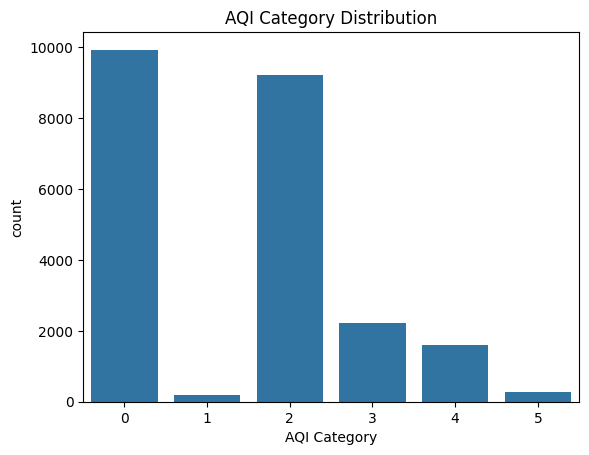

In [21]:
# Display AQI Category distribution

sns.countplot(x="AQI Category", data=df)
plt.title("AQI Category Distribution")
plt.show()

Countplot shows the number of records in each AQI category.

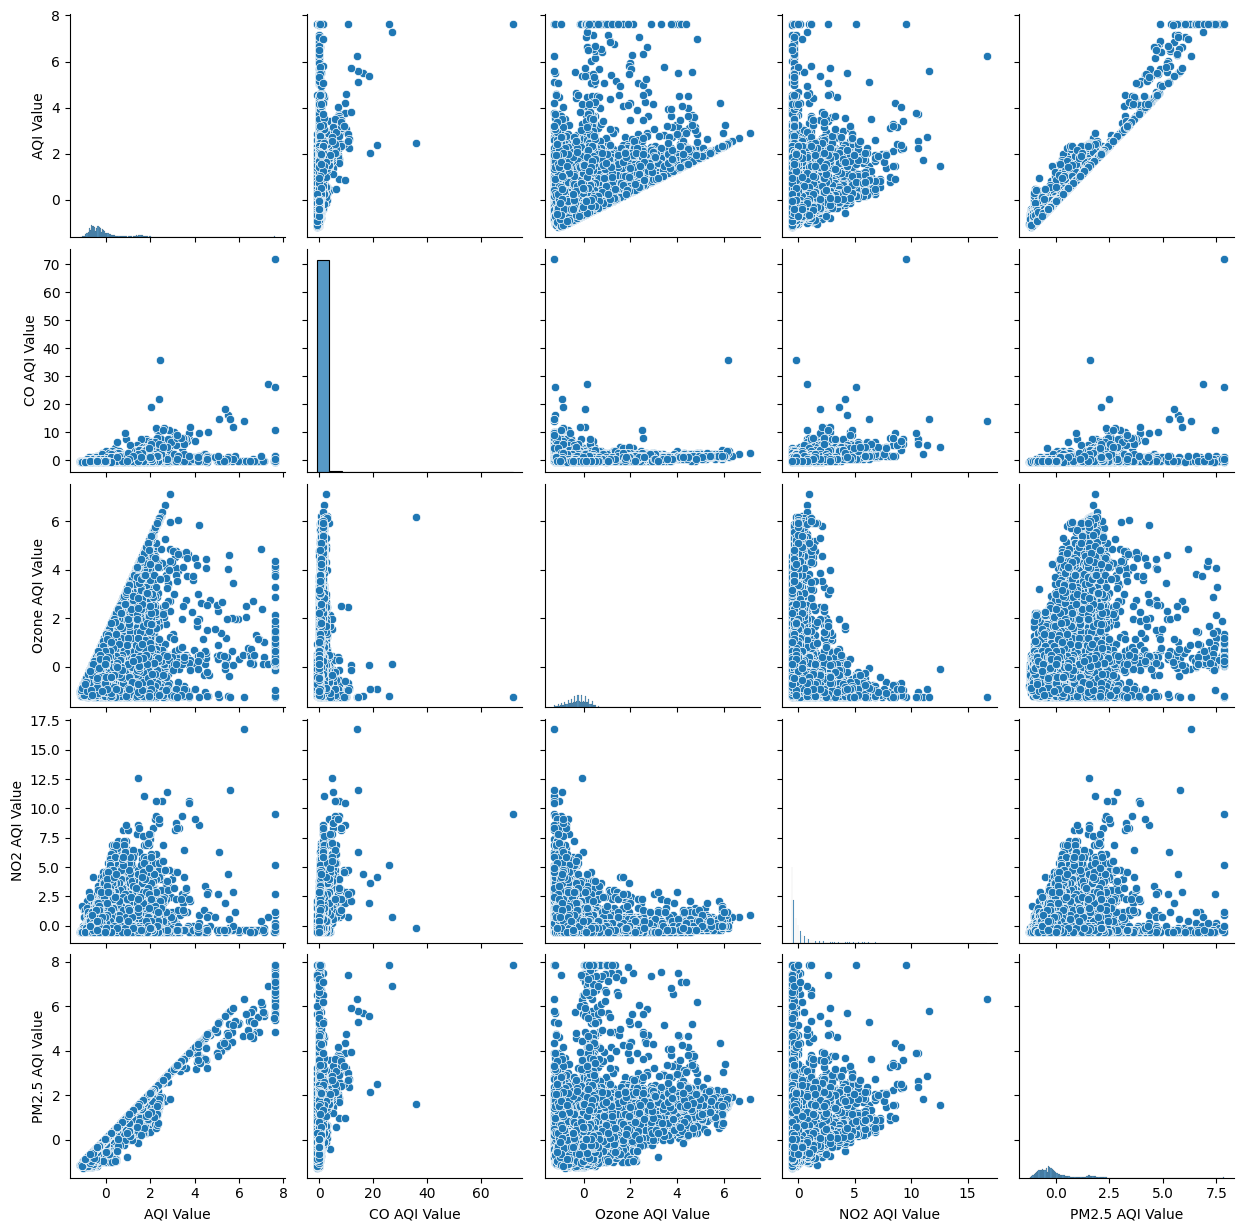

In [22]:
# Display relationship between numerical features

sns.pairplot(df[[
    "AQI Value",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]])

plt.show()

Insights

1. Imported the Global Air Pollution dataset successfully.
2. Checked dataset shape, columns and data types.
3. Identified missing values in Country and City columns.
4. Filled missing values using Mode because they are categorical columns.
5. Created a new feature called Total Pollution Index.
6. Converted categorical columns into numerical values using LabelEncoder.
7. Applied StandardScaler to normalize numerical features.
8. Used Seaborn visualizations such as Heatmap, Histogram, Boxplot, Countplot and Pairplot to understand relationships and data distribution.
9. The dataset is now clean and ready for Machine Learning.

I**nsights**

• The dataset contains global air pollution information for different countries and cities.

• AQI Value depends on different pollutant values such as CO, Ozone, NO2 and PM2.5.

• PM2.5 is one of the major pollutants affecting overall air quality.

• Missing values were found only in Country and City columns and were handled using Mode.

• A new feature, Total Pollution Index, was created to represent overall pollution.

• Categorical columns were converted into numerical values using Label Encoding.

• Numerical columns were standardized using StandardScaler.

• Heatmap was used to understand relationships between numerical features.

• Histogram showed the distribution of AQI values.

• Boxplot helped identify possible outliers.

• Countplot displayed the frequency of AQI categories.

• The dataset is now clean, preprocessed and ready for machine learning analysis.